In [1]:
# Parameters
name      = ""
fits_path = ""

In [2]:
# Parameters
name = "LVM-30Dor-6563_G15"
fits_path = "fits_ready/LVM-30Dor-6563_G15.fits"


In [3]:
import time
start_time=time.time()

In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult


# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#import strucfunc                   
from strucfunc import sosflog
import fit_structure_function
import ci_results_compiler
import bfunc
import bplot

# User function

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_line_panels(line_df, *, mark_func=None, s=25,
                     xcol="RAdeg", ycol="DEdeg",
                     flux_col="log_F", vcol="V_mean",
                     flux_cmap="magma", v_cmap="RdBu_r",
                     invert_ra=True, figsize=(14, 7),
                     titles=("Log Flux", "V_mean - <V_mean>"),
                     cbar_labels=("Flux", "V_mean - mean")):
    """
    Plot two panels for a given line DataFrame:
      (1) flux_col map
      (2) mean-subtracted vcol map

    Parameters
    ----------
    line_df : pandas.DataFrame
        Must contain xcol, ycol, flux_col, vcol.
    mark_func : callable or None
        Function like mark_points(ax) to annotate points on each axis.
    s : float
        Marker size for scatter.
    invert_ra : bool
        If True, invert x-axis (RA convention).
    """

    required = [xcol, ycol, flux_col, vcol]
    missing = [c for c in required if c not in line_df.columns]
    if missing:
        raise ValueError(f"Missing columns in line_df: {missing}")

    with sns.axes_style("darkgrid"):
        fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

        # Panel 1: log flux
        sc1 = ax[0].scatter(line_df[xcol], line_df[ycol], s=s, c=line_df[flux_col], cmap=flux_cmap)
        if invert_ra:
            ax[0].invert_xaxis()
        ax[0].set_xlabel("RA (deg)")
        ax[0].set_ylabel("Dec (deg)")
        ax[0].set_title(titles[0])
        if callable(mark_func):
            mark_func(ax[0])
        fig.colorbar(sc1, ax=ax[0], label=cbar_labels[0])

        # Panel 2: mean-subtracted velocity
        v1 = line_df[vcol] - line_df[vcol].mean()
        sc2 = ax[1].scatter(line_df[xcol], line_df[ycol], s=s, c=v1, cmap=v_cmap)
        if invert_ra:
            ax[1].invert_xaxis()
        ax[1].set_xlabel("RA (deg)")
        ax[1].set_ylabel("Dec (deg)")
        ax[1].set_title(titles[1])
        if callable(mark_func):
            mark_func(ax[1])
        fig.colorbar(sc2, ax=ax[1], label=cbar_labels[1])

    return fig, ax


# Velocity Field

In [6]:
from astropy.table import Table

data_in = Table.read("fits_ready/" + name + ".fits", hdu=name)
data_frame = data_in.to_pandas()

In [7]:
with fits.open("fits_ready/" + name + ".fits") as hdul:
    hdr = hdul[0].header

hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
FILE    = 'LVM-30Dor-6563_G15' / Fits file name                                 
NAME_ID = 'LVM-30Dor-H-X_G15'  / pipeline identifier                            
REG     = 'NGC 2070'           / Region catalog name                            
NAME_REG= '30 Doradus'         / Region name                                    
REG_ID  = '30Dor   '           / Region identifier                              
TYPE_OBJ= 'H II region'        / Type object                                    
DIST    =                50000 / Distance in parsecs                            
INSTR   = 'LVM     '           / Instrument                                     
LINE    = 'H$\alpha$'       

In [8]:
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
#noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

In [9]:
hdul.info()

Filename: fits_ready/LVM-30Dor-6563_G15.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      


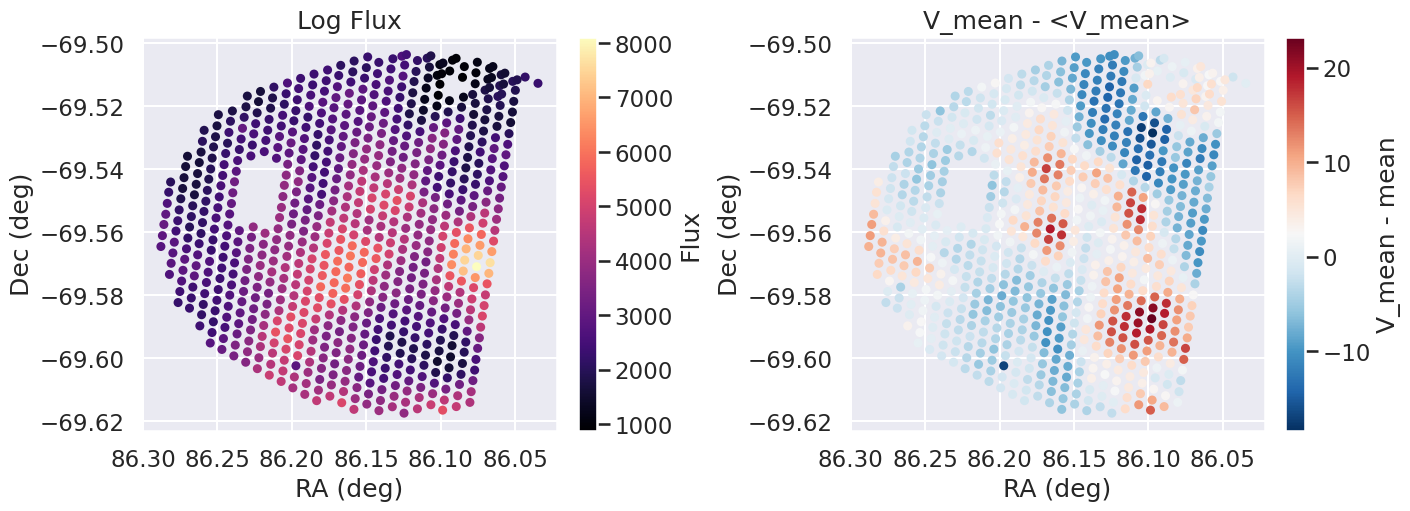

In [10]:
fig, ax = plot_line_panels(data_frame, invert_ra=True,figsize=(14, 5))
plt.show()

In [11]:
data_frame

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
0,86.068199,-69.511435,-9.470584,1301.2496,0.8416,258.9199,268.390484
1,86.091982,-69.505361,-11.940366,1005.0865,0.7996,256.5144,268.454766
2,86.078434,-69.516261,-2.913206,1683.2947,0.8565,265.4525,268.365706
3,86.102216,-69.510184,-6.914130,1076.0595,0.9076,261.5159,268.430030
4,86.125984,-69.504104,-19.198794,2637.2130,0.7323,249.2957,268.494494
...,...,...,...,...,...,...,...
744,86.161293,-69.515874,-11.038113,3158.5558,0.8564,257.4055,268.443613
745,86.185041,-69.509781,-11.707871,2365.1422,0.7787,256.8005,268.508371
746,86.158089,-69.505635,-15.950069,2074.6128,0.7405,252.5629,268.512969
747,86.134338,-69.511725,-20.575728,2727.2559,0.7426,247.8726,268.448328


# Structure function

In [12]:
#data_frame.columns=['X','Y','RV','I','Sig']
base_names = ['X', 'Y', 'RV', 'I', 'Sig']
data_frame.columns = base_names + list(data_frame.columns[5:])

In [13]:
table = sosflog(data_frame, 0.05, 3600)

/Users/javier/miniconda3/envs/viento/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/javier/miniconda3/envs/viento/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/javier/LVM_30dor/subfields_subrot/r50pc-HI-6563/py_modules/strucfunc.py:284: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_gui

In [14]:
s = 0.5 * (table[('s', 'min')] + table[('s', 'max')])*pc
e_s = 0.5 * (table[('s', 'max')] - table[('s', 'min')])*pc
b2 = table[('dV2', 'mean')]
ng = table[('dV2', 'count')]
e_b2 = table[('dV2', 'std')] / np.sqrt(ng)

In [15]:
#"Sum dv^2":
#"Sum weights":
#"Sum w * dv^2"
#"N pairs":
#"Weighted B(r)"

Br_results = {
    'log10 r'        : np.log10(s),
    'r'              : s,
    'r_err'          : e_s,
    "Unweighted B(r)": b2,
    'Unweighted B(r)_err' : e_b2
}

Br_results_ = pd.DataFrame(Br_results)
Br = Br_results_ 

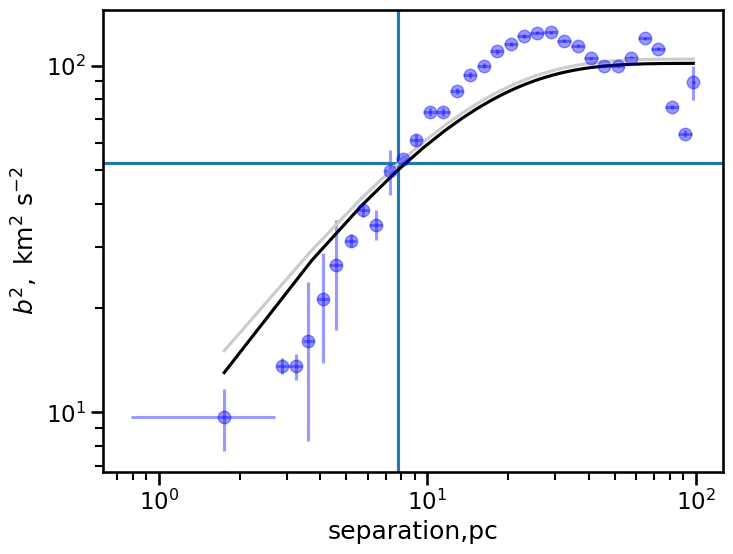

In [16]:
r0    = np.interp(sig2, b2[1:35], s[1:35])
ra = r0
m     = 1
noise = 0

rgrid = np.linspace(s.min(), s.max())

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(s, b2, yerr=e_b2, xerr=e_s, fmt='o', alpha=0.4,color="blue")

ax.axhline(sig2, ls='-')
ax.axvline(r0, ls='-')

ax.plot(rgrid, bfunc.bfunc00s(rgrid, r0, sig2, m), color="0.8")
ax.plot(rgrid, bfunc.bfunc03s(rgrid, r0, sig2, m, s0, noise), color="black")
#ax.plot(rgrid, bfunc.bfunc04s(rgrid, r0, sig2, m, s0, noise, box_size), color="black")


ax.set(xscale='log', yscale='log', 
       xlabel='separation,pc',
       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
      )
None

plt.show()



# Export

In [17]:
df =  Br_results_.copy()

# Flatten MultiIndex columns like ('s','count') -> "s_count"
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ["_".join(map(str, col)).strip() for col in df.columns.to_flat_index()]
else:
    df.columns = [str(c) for c in df.columns]

# (Optional) drop index to avoid it becoming an extra column
df = df.reset_index(drop=True)

t = Table.from_pandas(df)
new_hdu = fits.BinTableHDU(t, name="TABLE")

In [18]:
#with fits.open(fits_path, mode="readonly") as hdul:
#    hdus = [h.copy() for h in hdul]   # copy existing HDUs

#hdus.append(new_hdu)
#fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [19]:
with fits.open(fits_path, memmap=False) as hdul:
    hdus = [h.copy() for h in hdul]

# FITS EXTNAMEs are effectively case-insensitive; astropy reports them uppercase.
target = "TABLE"
idxs = [i for i, h in enumerate(hdus) if h.name.upper() == target]

if idxs:
    i0 = idxs[0]
    # Optional: preserve existing header cards (metadata) from old PARAMETERS
    old_hdr = hdus[i0].header.copy()
    hdus[i0] = new_hdu
    # Keep old metadata, then ensure EXTNAME stays correct
    hdus[i0].header.update(old_hdr)
    hdus[i0].name = target
    # Remove any additional duplicates if they exist
    for j in reversed(idxs[1:]):
        del hdus[j]
else:
    # If it doesn't exist, add it
    hdus.append(new_hdu)

fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [20]:
with fits.open(fits_path) as hdul:
    hdul.info()

Filename: fits_ready/LVM-30Dor-6563_G15.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      29   ()      
  1  LVM-30DOR-6563_G15    1 BinTableHDU     23   749R x 7C   [D, D, D, D, D, D, D]   
  2  TABLE         1 BinTableHDU     19   33R x 5C   [D, D, D, D, D]   


In [21]:
# Test import

from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
df_loaded = t.to_pandas()


In [22]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 4.354528903961182 seconds ---
